<a href="https://colab.research.google.com/github/gy22ew2/GEOG5990M-V2/blob/main/WorkingAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Uncovering the relationship between GCSE results and deprivation in Stockport.
This notebook aims to investigate the relationship between GCSE attainment and deprivation in Stockport in 2015 (the most recent available data for this study area).

This research is important since the Department for Education found that lifetime earnings and future employment are, on average, increased when GCSE attainment is higher (Hodge et al, 2021). Uncovering the relationship between GCSE attainment and deprivation may therefore provide useful understanding for future public good since Stockport Council will be able to target support to the areas that need it most.

# Importing the require packages
Below include the packages required to run the following code successfully.

In [ ]:
#Importing required packages for data visualisation and spatial analysis
!pip install contextily
!pip install geoplot
!pip install git+https://github.com/pmdscully/geo_northarrow.git
import geopandas as gpd
import numpy as np
import geoplot as gplt
import geoplot.crs as gcrs
from geo_northarrow import add_north_arrow
import contextily as ctx
import pyproj
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn import cluster
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 84.0 MB/s eta 0:00:00
  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-ymnbb2re
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-ymnbb2re
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit c530ad3f9558d05355543e9fe7671f26cd0ffa02
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for geo_northarrow: filename=geo_northarrow-0.2.0a0-py3-none-any.whl size=14940 sha256=9db6029c33cbd63d7e1237a920d268c2bf852bed1c189f00a6a07f807eaa5593
  Stored in directory: /tmp/pip-ephem-wheel-cache-adfmg35j/wheels/d7/28/6c/cb006605c19bc4f58db715626f7113a6858d8c002e8c52fa80
Successfully built geo_northarrow


# Data Sources
GCSE data = https://datamillnorth.org/dataset/stockport-gcse-results-vdmqm (Data Mill North, 2017)

IMD data = https://www.gov.uk/government/statistics/english-indices-of-deprivation-2015 (Gov.Uk, 2015)

LSOA boundaries = https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2011-boundaries-ew-bfc-v3/explore?location=53.391499%2C-2.144144%2C13 (Open Geography Portal, 2023)

Both IMD and GCSE data used in this research is from 2015 (the most up-to-date version which both datasets include) and thus the LSOA boundaries in this report are for 2011 which may mean certain boundaries are different from the 2021 boundaries.

In [ ]:
#Loading in the data for this research
#GCSE_Results = pd.read_csv("https://github.com/gy22ew2/GEOG5990M/raw/refs/heads/main/GCSE_Results.csv")
#IMD = pd.read_csv("https://github.com/gy22ew2/GEOG5990M/raw/refs/heads/main/IMD%202015.csv")
#LSOA = gpd.read_file("https://github.com/gy22ew2/GEOG5990M/raw/refs/heads/main/StockportLSOA.gpkg")
GCSE_Results = pd.read_csv("GCSE_Results(in).csv")
IMD = pd.read_csv("IMD 2015.csv")
LSOA = gpd.read_file("StockportLSOA.gpkg")



# Pre-processing data
All data was initially explored to understand its structure, column names and whether there are any missing values. To keep the data efficient and clean, unwanted columns were dropped and the wanted column names were changed as and when seen necessary.

In [ ]:
#Understanding the first 10 rows of data
GCSE_Results.head(10)

,ogc_fid,lsoa11cd,lsoa11nm,lsoa11nmw,2006K4Lar,2006K4Ach,2006PerAC,2007K4Lar,2007K4Ach,2007PerAC,...,2012PerAC,2013K4Lar,2013K4Ach,2013PerAC,2014K4Lar,2014K4Ach,2014PerAC,2015K4Lar,2015K4Ach,2015PerAC
0,5601,E01005761,Stockport 026A,Stockport 026A,22.0,4.0,18.18,NaN,NaN,8.70,...,62.50,19.0,13.0,68.42,28.0,14.0,50.00,NaN,NaN,42.9
1,5710,E01005870,Stockport 015A,Stockport 015A,18.0,9.0,50.00,18.0,9.0,50.00,...,44.44,14.0,7.0,50.00,13.0,9.0,69.23,NaN,NaN,33.3
2,5711,E01005871,Stockport 015B,Stockport 015B,14.0,7.0,50.00,16.0,4.0,25.00,...,46.67,20.0,14.0,70.00,15.0,4.0,26.67,NaN,NaN,42.9
3,5583,E01005743,Stockport 009A,Stockport 009A,17.0,8.0,47.06,20.0,10.0,50.00,...,76.47,17.0,9.0,52.94,18.0,12.0,66.67,NaN,NaN,25.0
4,5584,E01005744,Stockport 009B,Stockport 009B,NaN,NaN,16.67,17.0,8.0,47.06,...,69.23,18.0,10.0,55.56,NaN,NaN,27.27,NaN,NaN,27.3
5,5585,E01005745,Stockport 005A,Stockport 005A,23.0,12.0,52.17,19.0,9.0,47.37,...,66.67,18.0,13.0,72.22,18.0,7.0,38.89,12.0,4.0,33.3
6,5586,E01005746,Stockport 005B,Stockport 005B,15.0,4.0,26.67,23.0,5.0,21.74,...,63.64,9.0,4.0,44.44,NaN,NaN,10.00,NaN,NaN,12.5
7,5587,E01005747,Stockport 005C,Stockport 005C,23.0,13.0,56.52,24.0,18.0,75.00,...,70.00,17.0,11.0,64.71,10.0,7.0,70.00,21.0,9.0,42.9
8,5588,E01005748,Stockport 005D,Stockport 005D,19.0,9.0,47.37,8.0,6.0,75.00,...,92.31,9.0,8.0,88.89,15.0,12.0,80.00,12.0,8.0,66.7
9,5589,E01005749,Stockport 009C,Stockport 009C,23.0,10.0,43.48,15.0,12.0,80.00,...,60.00,18.0,12.0,66.67,21.0,7.0,33.33,12.0,4.0,33.3


In [ ]:
#Finding how many columns and rows the dataset has to understand the rough size of the data
GCSE_Results.shape

(190, 34)

In [ ]:
#Understanding the datatypes of the  dataset
GCSE_Results.dtypes

,0
ogc_fid,int64
lsoa11cd,object
lsoa11nm,object
lsoa11nmw,object
2006K4Lar,float64
2006K4Ach,float64
2006PerAC,float64
2007K4Lar,float64
2007K4Ach,float64
2007PerAC,float64


In [ ]:
#Getting all column titles to keep the only one we want to know which is '2015PerAc' meaning the Percentage of pupils achieving at least 5 A*-C including English and Maths
GCSE_Results.columns

Index(['ogc_fid', 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw', '2006K4Lar',
       '2006K4Ach', '2006PerAC', '2007K4Lar', '2007K4Ach', '2007PerAC',
       '2008K4Lar', '2008K4Ach', '2008PerAC', '2009K4Lar', '2009K4Ach',
       '2009PerAC', '2010K4Lar', '2010K4Ach', '2010PerAC', '2011K4Lar',
       '2011K4Ach', '2011PerAC', '2012K4Lar', '2012K4Ach', '2012PerAC',
       '2013K4Lar', '2013K4Ach', '2013PerAC', '2014K4Lar', '2014K4Ach',
       '2014PerAC', '2015K4Lar', '2015K4Ach', '2015PerAC'],
      dtype='object')

In [ ]:
#Removing said columns
GCSE_Results = GCSE_Results.drop(['2006K4Lar',
       '2006K4Ach', '2006PerAC', '2007K4Lar', '2007K4Ach', '2007PerAC',
       '2008K4Lar', '2008K4Ach', '2008PerAC', '2009K4Lar', '2009K4Ach',
       '2009PerAC', '2010K4Lar', '2010K4Ach', '2010PerAC', '2011K4Lar',
       '2011K4Ach', '2011PerAC', '2012K4Lar', '2012K4Ach', '2012PerAC',
       '2013K4Lar', '2013K4Ach', '2013PerAC', '2014K4Lar', '2014K4Ach',
       '2014PerAC', '2015K4Lar', '2015K4Ach'], axis='columns')

In [ ]:
#Checking the column has been removed
GCSE_Results.columns

Index(['ogc_fid', 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw', '2015PerAC'], dtype='object')

In [ ]:
#Changing '2015PerAc' name to make it more clear
GCSE_Results = GCSE_Results.rename(columns={'2015PerAC': '% Attainment of 5 GCSEs' })

In [ ]:
#Seeing the change in action
GCSE_Results.columns

Index(['ogc_fid', 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw',
       '% Attainment of 5 GCSEs'],
      dtype='object')

In [ ]:
#Identifying if any cells contain no data
GCSE_Results.isna()

,ogc_fid,lsoa11cd,lsoa11nm,lsoa11nmw,% Attainment of 5 GCSEs
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
185,False,False,False,False,False
186,False,False,False,False,False
187,False,False,False,False,False
188,False,False,False,False,False


In [ ]:
#Seeing the total number of null rows
GCSE_Results.isnull().sum()

,0
ogc_fid,0
lsoa11cd,0
lsoa11nm,0
lsoa11nmw,0
% Attainment of 5 GCSEs,0


In [ ]:
#Getting the first 5 rows of data
IMD.head(5)

,LSOA code (2011),LSOA name (2011),Local Authority District code (2013),Local Authority District name (2013),Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)
0,E01005886,Stockport 001A,E08000007,Stockport,"5,601",2
1,E01005888,Stockport 001B,E08000007,Stockport,"12,183",4
2,E01005889,Stockport 001C,E08000007,Stockport,"7,781",3
3,E01005891,Stockport 001D,E08000007,Stockport,"20,622",7
4,E01005894,Stockport 001E,E08000007,Stockport,"13,124",4


In [ ]:
#Comparing the shape of this dataset to the GCSE one.
IMD.shape

(190, 6)

In [ ]:
#Checking if there are any missing values in the dataset.
IMD.isnull().sum()

,0
LSOA code (2011),0
LSOA name (2011),0
Local Authority District code (2013),0
Local Authority District name (2013),0
Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived),0
Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),0


In [ ]:
#Dropping the unwanted column to make a cleaner dataset.
IMD = IMD.drop(['Index of Multiple Deprivation (IMD) Rank (where 1 is most deprived)'], axis='columns')

In [ ]:
#Checking that the column was successfully dropped.
IMD.columns

Index(['LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2013)',
       'Local Authority District name (2013)',
       'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)'],
      dtype='object')

In [ ]:
#Renaming the column to a shorter name.
IMD = IMD.rename(columns={'Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)': 'IMD Decile' })

In [ ]:
IMD.dtypes

,0
LSOA code (2011),object
LSOA name (2011),object
Local Authority District code (2013),object
Local Authority District name (2013),object
IMD Decile,int64


In [ ]:
#Seeing the first 5 rows of the LSOA data.
LSOA.head(5)

,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,GCSE_Results_ogc_fid,GCSE_Results_lsoa11nm,...,GCSE_Results_2013K4Lar,GCSE_Results_2013K4Ach,GCSE_Results_2013PerAC,GCSE_Results_2014K4Lar,GCSE_Results_2014K4Ach,GCSE_Results_2014PerAC,GCSE_Results_2015K4Lar,GCSE_Results_2015K4Ach,GCSE_Results_2015PerAC,geometry
0,E01005743,Stockport 009A,392026,391288,-2.12144,53.4183,5560.947807,5f5d3d33-4de9-4c0e-91b9-a7b579bc5bd7,5583,Stockport 009A,...,17,9,52.94,18,12,66.67,,,25,"MULTIPOLYGON (((392009.027 392109.858, 392009...."
1,E01005744,Stockport 009B,392319,392529,-2.11706,53.4295,11514.300163,ed916925-5b87-46a9-93ce-73fba40abef3,5584,Stockport 009B,...,18,10,55.56,,,27.27,,,27.3,"MULTIPOLYGON (((392108.814 393443.094, 392101...."
2,E01005745,Stockport 005A,393598,392783,-2.09782,53.4318,5704.937386,cf1ae05a-2216-4447-ba0e-3ffe1cde6185,5585,Stockport 005A,...,18,13,72.22,18,7,38.89,12,4,33.3,"MULTIPOLYGON (((394019 393422.45, 394023.194 3..."
3,E01005746,Stockport 005B,393444,392024,-2.10012,53.4250,3288.573613,929653c4-e32c-46ea-9b55-4ef27d7159e0,5586,Stockport 005B,...,9,4,44.44,,,10,,,12.5,"MULTIPOLYGON (((393606.571 392407.81, 393609 3..."
4,E01005747,Stockport 005C,394134,392595,-2.08975,53.4301,4410.605682,2811887b-55d2-4b79-900d-65857f81df3d,5587,Stockport 005C,...,17,11,64.71,10,7,70,21,9,42.9,"MULTIPOLYGON (((394398.116 393083.503, 394404...."


In [ ]:
#Checking the columns in the LSOA data which has a lot of columns due to 'cutting' UK LSOAs to the study area on GIS. These columns will be dropped and then the datasets will be combined in a later step in python.
LSOA.columns

Index(['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng',
       'GlobalID', 'GCSE_Results_ogc_fid', 'GCSE_Results_lsoa11nm',
       'GCSE_Results_lsoa11nmw', 'GCSE_Results_2006K4Lar',
       'GCSE_Results_2006K4Ach', 'GCSE_Results_2006PerAC',
       'GCSE_Results_2007K4Lar', 'GCSE_Results_2007K4Ach',
       'GCSE_Results_2007PerAC', 'GCSE_Results_2008K4Lar',
       'GCSE_Results_2008K4Ach', 'GCSE_Results_2008PerAC',
       'GCSE_Results_2009K4Lar', 'GCSE_Results_2009K4Ach',
       'GCSE_Results_2009PerAC', 'GCSE_Results_2010K4Lar',
       'GCSE_Results_2010K4Ach', 'GCSE_Results_2010PerAC',
       'GCSE_Results_2011K4Lar', 'GCSE_Results_2011K4Ach',
       'GCSE_Results_2011PerAC', 'GCSE_Results_2012K4Lar',
       'GCSE_Results_2012K4Ach', 'GCSE_Results_2012PerAC',
       'GCSE_Results_2013K4Lar', 'GCSE_Results_2013K4Ach',
       'GCSE_Results_2013PerAC', 'GCSE_Results_2014K4Lar',
       'GCSE_Results_2014K4Ach', 'GCSE_Results_2014PerAC',
       'GCSE_Results_2015K4

In [ ]:
#Dropping unwanted columns as explained above.
LSOA = LSOA.drop(['GCSE_Results_ogc_fid', 'GCSE_Results_lsoa11nm',
       'GCSE_Results_lsoa11nmw', 'GCSE_Results_2006K4Lar',
       'GCSE_Results_2006K4Ach', 'GCSE_Results_2006PerAC',
       'GCSE_Results_2007K4Lar', 'GCSE_Results_2007K4Ach',
       'GCSE_Results_2007PerAC', 'GCSE_Results_2008K4Lar',
       'GCSE_Results_2008K4Ach', 'GCSE_Results_2008PerAC',
       'GCSE_Results_2009K4Lar', 'GCSE_Results_2009K4Ach',
       'GCSE_Results_2009PerAC', 'GCSE_Results_2010K4Lar',
       'GCSE_Results_2010K4Ach', 'GCSE_Results_2010PerAC',
       'GCSE_Results_2011K4Lar', 'GCSE_Results_2011K4Ach',
       'GCSE_Results_2011PerAC', 'GCSE_Results_2012K4Lar',
       'GCSE_Results_2012K4Ach', 'GCSE_Results_2012PerAC',
       'GCSE_Results_2013K4Lar', 'GCSE_Results_2013K4Ach',
       'GCSE_Results_2013PerAC', 'GCSE_Results_2014K4Lar',
       'GCSE_Results_2014K4Ach', 'GCSE_Results_2014PerAC',
       'GCSE_Results_2015K4Lar', 'GCSE_Results_2015K4Ach',
       'GCSE_Results_2015PerAC'], axis = 'columns')

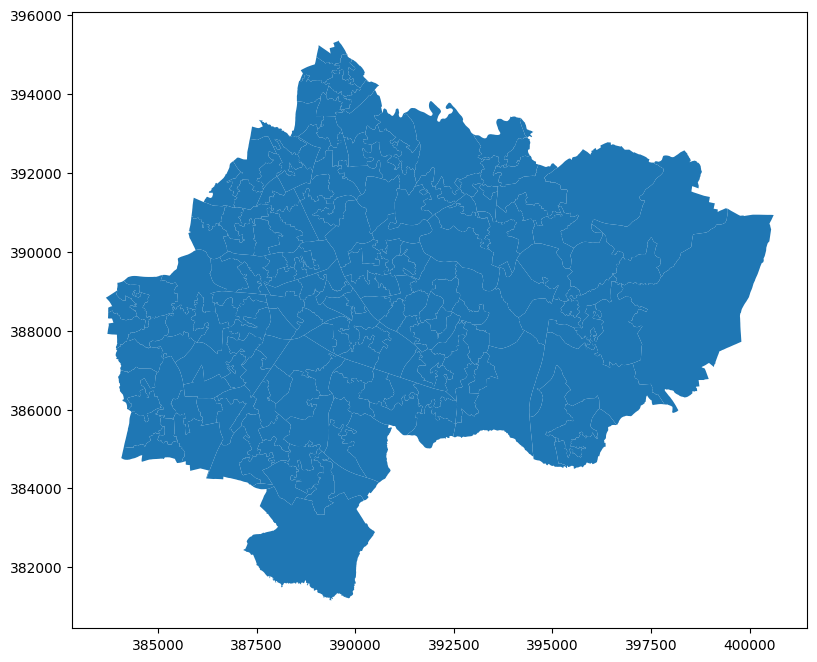

In [ ]:
# define the plot size and nummber of subplots (1 i.e. 1 plot)
f, ax = plt.subplots(1, figsize=(16, 8))
# plot the  leeds data, specifying the subplot axis
LSOA.plot(ax=ax)
# show the plot
plt.show()

In [ ]:
#Checking the crs of the data to ensure it is the British National Grid, which is the correct format to map Stockport.

LSOA.crs

<Projected CRS: EPSG:27700>
Name: OSGB36 / British National Grid
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: United Kingdom (UK) - offshore to boundary of UKCS within 49°45'N to 61°N and 9°W to 2°E; onshore Great Britain (England, Wales and Scotland). Isle of Man onshore.
- bounds: (-9.01, 49.75, 2.01, 61.01)
Coordinate Operation:
- name: British National Grid
- method: Transverse Mercator
Datum: Ordnance Survey of Great Britain 1936
- Ellipsoid: Airy 1830
- Prime Meridian: Greenwich

# Joining data

A 'common' column in all datasets was identified as the LSOA code, allowing for a master dataset which included the GCSE, IMD data and LSOA boundaries to be created. Once again, any unwanted columns were dropped to clean this 'master' dataset.

In [ ]:
#Rechecking columns for joining datasets
print(GCSE_Results.columns)
print(IMD.columns)
print(LSOA.columns)

Index(['ogc_fid', 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw',
       '% Attainment of 5 GCSEs'],
      dtype='object')
Index(['LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2013)',
       'Local Authority District name (2013)', 'IMD Decile'],
      dtype='object')
Index(['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng',
       'GlobalID', 'geometry'],
      dtype='object')


In [ ]:
#Joining the GCSE and IMD dataset because both datasets have LSOA codes.
GCSE_IMD = GCSE_Results.merge(IMD, how= 'left', left_on='lsoa11cd', right_on='LSOA code (2011)')

In [ ]:
#Checking the join worked.
GCSE_IMD.columns

Index(['ogc_fid', 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw',
       '% Attainment of 5 GCSEs', 'LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2013)',
       'Local Authority District name (2013)', 'IMD Decile'],
      dtype='object')

In [ ]:
#Exploring the new dataset.
GCSE_IMD.head(10)

,ogc_fid,lsoa11cd,lsoa11nm,lsoa11nmw,% Attainment of 5 GCSEs,LSOA code (2011),LSOA name (2011),Local Authority District code (2013),Local Authority District name (2013),IMD Decile
0,5601,E01005761,Stockport 026A,Stockport 026A,42.9,E01005761,Stockport 026A,E08000007,Stockport,3
1,5710,E01005870,Stockport 015A,Stockport 015A,33.3,E01005870,Stockport 015A,E08000007,Stockport,4
2,5711,E01005871,Stockport 015B,Stockport 015B,42.9,E01005871,Stockport 015B,E08000007,Stockport,4
3,5583,E01005743,Stockport 009A,Stockport 009A,25.0,E01005743,Stockport 009A,E08000007,Stockport,6
4,5584,E01005744,Stockport 009B,Stockport 009B,27.3,E01005744,Stockport 009B,E08000007,Stockport,3
5,5585,E01005745,Stockport 005A,Stockport 005A,33.3,E01005745,Stockport 005A,E08000007,Stockport,5
6,5586,E01005746,Stockport 005B,Stockport 005B,12.5,E01005746,Stockport 005B,E08000007,Stockport,1
7,5587,E01005747,Stockport 005C,Stockport 005C,42.9,E01005747,Stockport 005C,E08000007,Stockport,9
8,5588,E01005748,Stockport 005D,Stockport 005D,66.7,E01005748,Stockport 005D,E08000007,Stockport,10
9,5589,E01005749,Stockport 009C,Stockport 009C,33.3,E01005749,Stockport 009C,E08000007,Stockport,7


In [ ]:
#Ensuring the datasets still have no missing values.
GCSE_IMD['IMD Decile'].isnull().sum()

np.int64(0)

In [ ]:
#Dropping unwanted columns to keep the dataset clean.
GCSE_IMD = GCSE_IMD.drop([ 'LSOA code (2011)', 'LSOA name (2011)',
       'Local Authority District code (2013)',
       'Local Authority District name (2013)'], axis = 'columns')

In [ ]:
#Rechecking this new dataset.
GCSE_IMD.head(10)

,ogc_fid,lsoa11cd,lsoa11nm,lsoa11nmw,% Attainment of 5 GCSEs,IMD Decile
0,5601,E01005761,Stockport 026A,Stockport 026A,42.9,3
1,5710,E01005870,Stockport 015A,Stockport 015A,33.3,4
2,5711,E01005871,Stockport 015B,Stockport 015B,42.9,4
3,5583,E01005743,Stockport 009A,Stockport 009A,25.0,6
4,5584,E01005744,Stockport 009B,Stockport 009B,27.3,3
5,5585,E01005745,Stockport 005A,Stockport 005A,33.3,5
6,5586,E01005746,Stockport 005B,Stockport 005B,12.5,1
7,5587,E01005747,Stockport 005C,Stockport 005C,42.9,9
8,5588,E01005748,Stockport 005D,Stockport 005D,66.7,10
9,5589,E01005749,Stockport 009C,Stockport 009C,33.3,7


In [ ]:
#Seeing if there are any common columns between the LSOA dataset and the IMD_GCSE one.
LSOA.columns

Index(['LSOA11CD', 'LSOA11NM', 'BNG_E', 'BNG_N', 'LONG_', 'LAT', 'Shape_Leng',
       'GlobalID', 'geometry'],
      dtype='object')

In [ ]:
#Joining the datasets through the same columns and then exploring the final 'master' dataset.
LSOA_GCSE_IMD = pd.merge(LSOA, GCSE_IMD, left_on='LSOA11CD', right_on='lsoa11cd',how='left')
LSOA_GCSE_IMD.head()

,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry,ogc_fid,lsoa11cd,lsoa11nm,lsoa11nmw,% Attainment of 5 GCSEs,IMD Decile
0,E01005743,Stockport 009A,392026,391288,-2.12144,53.4183,5560.947807,5f5d3d33-4de9-4c0e-91b9-a7b579bc5bd7,"MULTIPOLYGON (((392009.027 392109.858, 392009....",5583,E01005743,Stockport 009A,Stockport 009A,25.0,6
1,E01005744,Stockport 009B,392319,392529,-2.11706,53.4295,11514.300163,ed916925-5b87-46a9-93ce-73fba40abef3,"MULTIPOLYGON (((392108.814 393443.094, 392101....",5584,E01005744,Stockport 009B,Stockport 009B,27.3,3
2,E01005745,Stockport 005A,393598,392783,-2.09782,53.4318,5704.937386,cf1ae05a-2216-4447-ba0e-3ffe1cde6185,"MULTIPOLYGON (((394019 393422.45, 394023.194 3...",5585,E01005745,Stockport 005A,Stockport 005A,33.3,5
3,E01005746,Stockport 005B,393444,392024,-2.10012,53.4250,3288.573613,929653c4-e32c-46ea-9b55-4ef27d7159e0,"MULTIPOLYGON (((393606.571 392407.81, 393609 3...",5586,E01005746,Stockport 005B,Stockport 005B,12.5,1
4,E01005747,Stockport 005C,394134,392595,-2.08975,53.4301,4410.605682,2811887b-55d2-4b79-900d-65857f81df3d,"MULTIPOLYGON (((394398.116 393083.503, 394404....",5587,E01005747,Stockport 005C,Stockport 005C,42.9,9


In [ ]:
#Dropping unwanted columns.
LSOA_GCSE_IMD = LSOA_GCSE_IMD.drop([ 'lsoa11cd', 'lsoa11nm', 'lsoa11nmw' ], axis = 'columns')
LSOA_GCSE_IMD.head()

,LSOA11CD,LSOA11NM,BNG_E,BNG_N,LONG_,LAT,Shape_Leng,GlobalID,geometry,ogc_fid,% Attainment of 5 GCSEs,IMD Decile
0,E01005743,Stockport 009A,392026,391288,-2.12144,53.4183,5560.947807,5f5d3d33-4de9-4c0e-91b9-a7b579bc5bd7,"MULTIPOLYGON (((392009.027 392109.858, 392009....",5583,25.0,6
1,E01005744,Stockport 009B,392319,392529,-2.11706,53.4295,11514.300163,ed916925-5b87-46a9-93ce-73fba40abef3,"MULTIPOLYGON (((392108.814 393443.094, 392101....",5584,27.3,3
2,E01005745,Stockport 005A,393598,392783,-2.09782,53.4318,5704.937386,cf1ae05a-2216-4447-ba0e-3ffe1cde6185,"MULTIPOLYGON (((394019 393422.45, 394023.194 3...",5585,33.3,5
3,E01005746,Stockport 005B,393444,392024,-2.10012,53.4250,3288.573613,929653c4-e32c-46ea-9b55-4ef27d7159e0,"MULTIPOLYGON (((393606.571 392407.81, 393609 3...",5586,12.5,1
4,E01005747,Stockport 005C,394134,392595,-2.08975,53.4301,4410.605682,2811887b-55d2-4b79-900d-65857f81df3d,"MULTIPOLYGON (((394398.116 393083.503, 394404....",5587,42.9,9


In [ ]:
#Checking for msising values.
LSOA_GCSE_IMD.isnull().sum()

,0
LSOA11CD,0
LSOA11NM,0
BNG_E,0
BNG_N,0
LONG_,0
LAT,0
Shape_Leng,0
GlobalID,0
geometry,0
ogc_fid,0


In [ ]:
#Ensuring the number of rows hasnt changed and the number of columns has.
LSOA_GCSE_IMD.shape

(190, 12)

# Statistical modelling

Spearman's rank correlation was selected as the statistical model since the IMD data is an ordinal variable, as it is in decile form (Hashash & Shiekh, 2022). This model showed that deprivation and GCSE attainment in Stockport in 2015 is strongly positively associated throuogh the final spearman correlation ceofficient of 0.72. Therefore, less deprived areas were more likely to have higher GCSE attainment.

In [ ]:
##CHATGPT
##The following prompt was asked "I want to do correlation analysis on my variables 'IMD Decile' and '% Attainment of 5 GCSEs' on python. Which correlation should I do and how to do I code this?"
#The following code allowed for the relationship between IMD and GCSE attainment to be understood numericly.
from scipy.stats import spearmanr

# keep only the two columns and drop missing values
correlation_data = GCSE_IMD[['IMD Decile', '% Attainment of 5 GCSEs']].dropna()

# run Spearman correlation
correlation, p_value = spearmanr(
    correlation_data['IMD Decile'],
    correlation_data['% Attainment of 5 GCSEs']
)

print("Spearman correlation coefficient:", correlation)
print("p-value:", p_value)

Spearman correlation coefficient: 0.7169076789213814
p-value: 2.8453634273775476e-31


# Non-spatial visualisation

A number of visualisation methods were created to highlight how the two datasets interact. As discussed prior, the scatter plot showed the positive relationship between IMD and GCSE attainment and also displayed why a Spearman's rank correlation was selected, seeing as the IMD data can be seen as ordinal (i.e. either 1,2,3..10). A boxplot was then chosen as a better method of visualisation since, it allowed for better, more detailed analysis due to the presence of a median line, and variation between each IMD decile and attainment rate. A histogram jointplot was then created, however whilst, the inclusion of bar graphs for each variables was interesting to see how they range in the dataset, the histogram itself was harder to see how both variables interacted together. Therefore, the final professional non-spatial output was a boxplot which included a suitable title, accessible colour palette and axis labels.

This visualisation is inteded for policymakers as it presents the evidence that GCSE attainment, and therefore future life experiences such as employment and salary, differes across deprivation deciles. This knowledge could impact future policy on where to focus council spending in schools.

<Axes: xlabel='IMD Decile', ylabel='% Attainment of 5 GCSEs'>

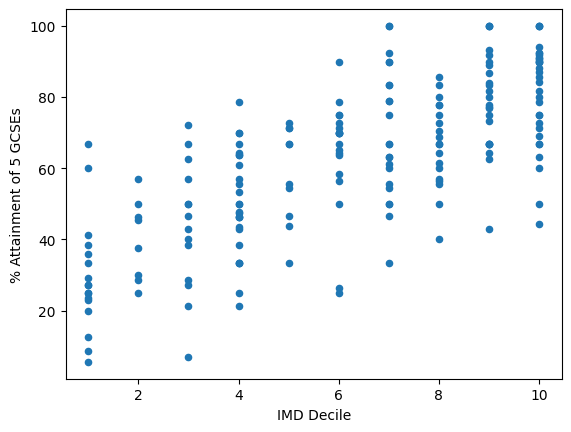

In [ ]:
#Creating a basic scatter plot to see the relationship between IMD Deciles and GCSE results.
GCSE_IMD.plot.scatter(x='IMD Decile', y='% Attainment of 5 GCSEs')

<Axes: xlabel='IMD Decile', ylabel='% Attainment of 5 GCSEs'>

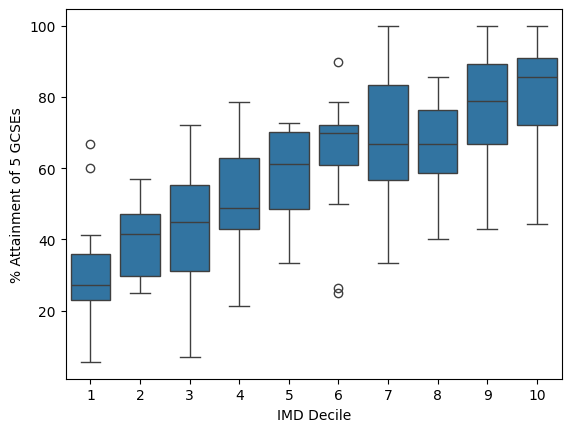

In [ ]:
#Seeing the same relationship through a boxplot.
sns.boxplot(x='IMD Decile', y='% Attainment of 5 GCSEs', data=GCSE_IMD)

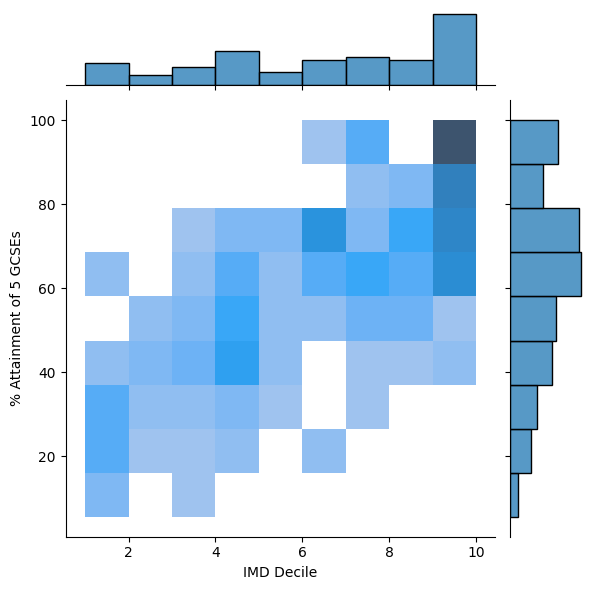

In [ ]:
#Creating a joinplot with a histogram.
sns.jointplot(x='IMD Decile', y='% Attainment of 5 GCSEs', kind = 'hist', data=GCSE_IMD)

/tmp/ipykernel_9152/3766402209.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='IMD Decile',


Text(0, 0.5, 'Pupils achieving 5 A*-C GCSEs incl. English and Maths/ %')

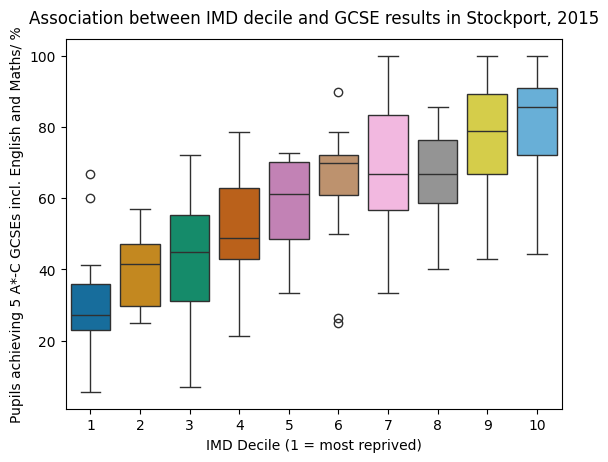

In [ ]:
#Creating a boxplot of IMD Decile and GCSE results using a colourblind pallette.
sns.boxplot(x='IMD Decile',
            y='% Attainment of 5 GCSEs',
            data=GCSE_IMD,
           palette= 'colorblind')
#Setting the title and axis titles as needed.
plt.title(
    'Association between IMD decile and GCSE results in Stockport, 2015',
    y=1.02)
plt.xlabel("IMD Decile (1 = most reprived)")
plt.ylabel("Pupils achieving 5 A*-C GCSEs incl. English and Maths/ %")


# Spatial Visualisation

Two simple spatial visualisations were initially created to identify if any patterns were present in the distribution of deprivation and GCSE attainment separetely across LSOAs in Stockport in 2015.  

These two visualisations showed that Stockport had large variation in GCSE attainment and deprivation levels across LSOAs. The central northern LSOAs had some bunching of purple which indicated lower levels of GCSE attainment and higher levels of deprivation. The Southern pocket of yellow LSOAs in the deprivation map suggests that this wider area is the least deprived part of Stockport. The same area in the GCSE attainment map is shown to be green and thus have high levels of attainment. This is unsurprising after the Spearman’s rank correlation analysis. The third visualisation in this section makes comparison easier by putting the two maps in the same figure with labelled legends for easy understanding of what the maps are showing. The comparison and patterns are not perfect between areas of high deprivation being the exact same as areas with low GCSE attainment however, once again this is unsurprising since the Spearman’s rank was 0.72, not 1 for example.  

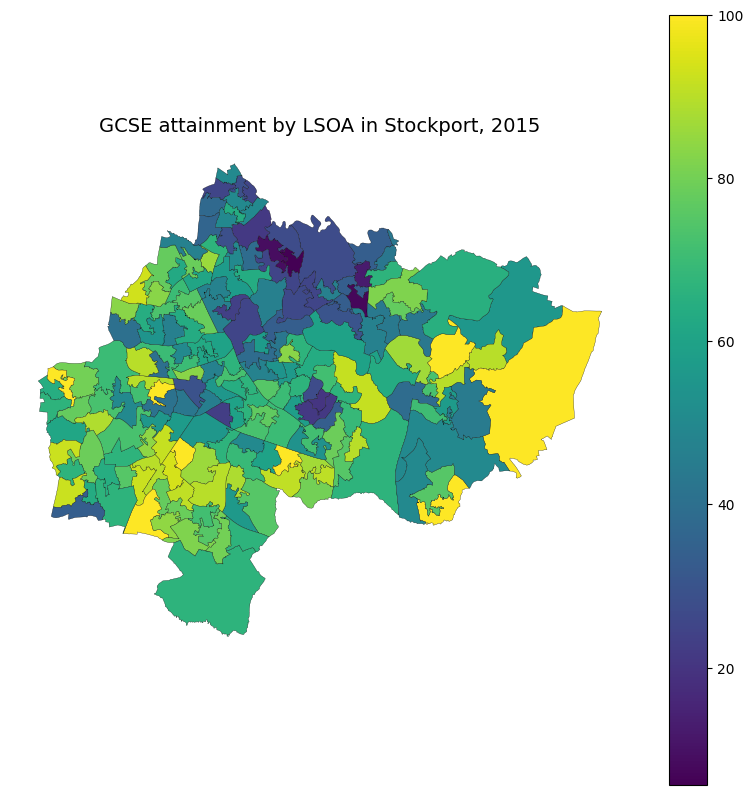

In [ ]:
#Setting the fiure size.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
#Plotting Stockport's GCSE attainment with a legend.
LSOA_GCSE_IMD.plot(
    column='% Attainment of 5 GCSEs',
    ax=ax,
    legend=True,
    edgecolor='black',
    linewidth=0.2
)

#Setting the title and turning the axis of.
ax.set_title('GCSE attainment by LSOA in Stockport, 2015', fontsize=14)
ax.axis('off')

#Showing the map.
plt.show()

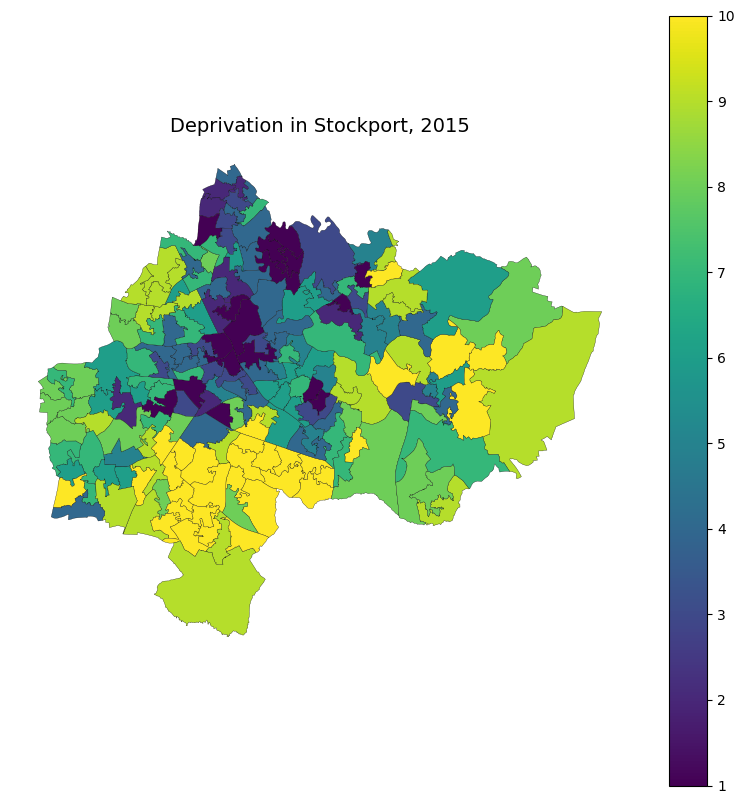

In [ ]:
#Setting the figure size.
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

#Plotting Stockport's IMD Deciles for each LSOA with a legend.

LSOA_GCSE_IMD.plot(
    column='IMD Decile',
    ax=ax,
    legend=True,
    edgecolor='black',
    linewidth=0.2
)
#Setting the title and turning the axis of.
ax.set_title('Deprivation in Stockport, 2015', fontsize=14)
ax.axis('off')
#Showing the map.
plt.show()

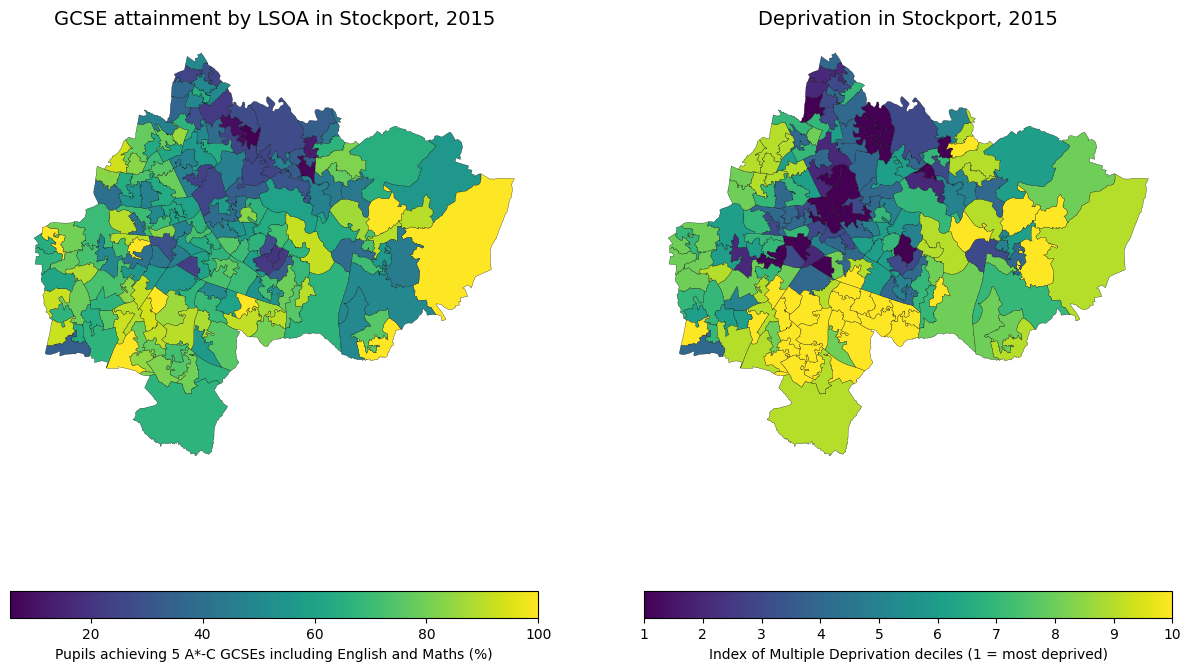

In [ ]:
#Setting the size for the figue that inclued 2 maps.
fig, ax = plt.subplots(1, 2, figsize=(15, 10))

#Plotting GCSE attainment for the first map and ensuring the legend is correctly named and displayed.
#Using an accessible colourscheme.
LSOA_GCSE_IMD.plot(
    ax=ax[0],
    column='% Attainment of 5 GCSEs',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={
        'label': "Pupils achieving 5 A*-C GCSEs including English and Maths (%)",
        'orientation': 'horizontal'
    },
    cmap = 'viridis'
)

#Setting an appropriate title and turning the axis off.
ax[0].set_title('GCSE attainment by LSOA in Stockport, 2015', fontsize=14)
ax[0].axis('off')

#Plotting IMD Deciles for the first map and ensuring the legend is correctly named and displayed.
#Using an accessible colourscheme.
LSOA_GCSE_IMD.plot(
    ax=ax[1],
    column='IMD Decile',
    legend=True,
    edgecolor='black',
    linewidth=0.2,
    legend_kwds={
        'label': "Index of Multiple Deprivation deciles (1 = most deprived)",
        'orientation': 'horizontal'
    },
    cmap='viridis'
)

#Setting an appropriate title.
ax[1].set_title('Deprivation in Stockport, 2015', fontsize=14)
ax[1].axis('off')

#Showing the map
plt.show()

# K-means clustering

To explore deprivation and GCSE attainment further in Stockport, K-means clustering was undertaken to group LSOAs by different characteristics (Bizxcel, 2023). This allowed for better understanding of specific LSOAs which may help policymakers identfy specific areas that require greater support than others. For example, the final visualisation included a cluster named 'Highly deprived with low GCSE attainment' which represents the LSOAs which have socioeconomic and educational disadvantages when compared to the rest of Stockport. A colourblind palette was chosen for cluster groups for accessible visualisations and simple cluster names were created for easier interpretation.


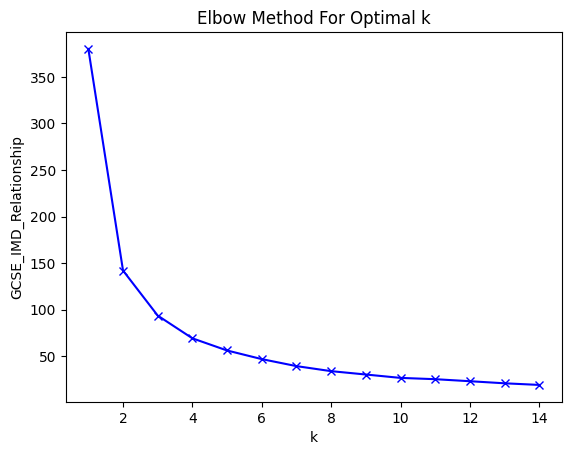

In [ ]:
##CHATGPT
#The following prompt was used in ChatGPT to see how to start the K means clustering correctly.
#"I want to do a K means clustering on my variables. How should i start this?"
#The standardizing code was then edited from Chatgpt's output to ensure vatiables were scaled correctly.

clustering_variables = LSOA_GCSE_IMD[['IMD Decile', '% Attainment of 5 GCSEs']].copy()

scaler = StandardScaler()
scaled_clustering_variables = scaler.fit_transform(clustering_variables)

#Create an empty list which will be filled later.
GCSE_IMD_Relationship = []

#getting a range of number from 1 to 15.
K = range(1,15)

#creating a k-means model of the two variables using up to 15 clusters and setting a random state.
for k in K:
    km = cluster.KMeans(n_clusters=k, init="random", random_state=123)
    km = km.fit(scaled_clustering_variables)

#calculating the sum of the squared distances
    GCSE_IMD_Relationship.append(km.inertia_)

#plotting the sum of the sqaured distances alongside cluster numbers.
plt.plot(K, GCSE_IMD_Relationship, 'bx-')
plt.xlabel('k')
plt.ylabel('GCSE_IMD_Relationship')
plt.title('Elbow Method For Optimal k')
plt.show()

In [ ]:
#Based on when the graph leveloeed out, I chose to choose to continue the clustering with 4 clusters.
km4 = cluster.KMeans(n_clusters=4,init="random", random_state=123)
km4cls = km4.fit(scaled_clustering_variables)

In [ ]:
#Looking at the cluster labels
km4cls.labels_

array([0, 0, 0, 0, 3, 3, 3, 0, 2, 0, 0, 0, 0, 0, 2, 0, 2, 2, 0, 0, 0, 2,
       1, 2, 3, 1, 3, 3, 1, 1, 3, 2, 3, 1, 2, 1, 3, 1, 0, 3, 3, 3, 1, 1,
       1, 1, 1, 3, 1, 1, 1, 1, 1, 1, 2, 2, 0, 3, 3, 1, 1, 2, 1, 1, 1, 1,
       1, 3, 3, 1, 3, 1, 1, 2, 2, 0, 1, 2, 2, 2, 2, 3, 3, 0, 3, 0, 0, 3,
       3, 3, 2, 0, 1, 3, 3, 2, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 1, 0, 1, 3,
       2, 1, 3, 3, 3, 1, 3, 1, 3, 1, 3, 3, 1, 2, 1, 1, 3, 0, 2, 2, 2, 0,
       1, 2, 2, 0, 2, 3, 1, 1, 1, 3, 1, 0, 0, 0, 2, 0, 3, 0, 2, 2, 0, 2,
       2, 3, 2, 2, 3, 0, 1, 1, 0, 1, 3, 1, 3, 2, 3, 3, 3, 2, 2, 2, 0, 0,
       0, 3, 0, 3, 1, 1, 1, 3, 3, 2, 1, 1, 1, 3], dtype=int32)

In [ ]:
#Looking at the cluster labels futher
LSOA_GCSE_IMD['Cluster'] = km4cls.labels_
LSOA_GCSE_IMD['Cluster'].head()

,Cluster
0,0
1,0
2,0
3,0
4,3


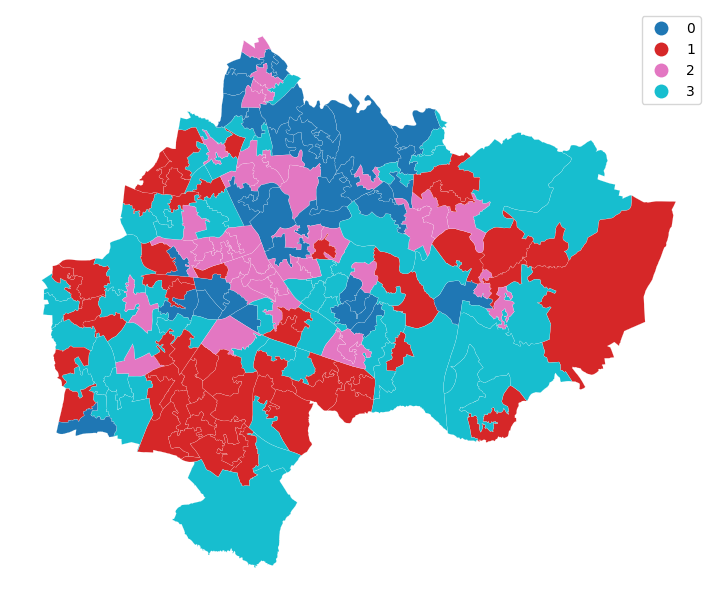

In [ ]:
#Setting the figure size correctly.
f, ax = plt.subplots(1, figsize=(9, 9))

#Mapping the clusters with the legend to show cluster distribution across Stockport.
LSOA_GCSE_IMD.plot(column='Cluster',  legend=True, categorical=True, \
         linewidth=0.1, edgecolor='white', ax=ax)

ax.set_axis_off()

#Showing the map
plt.show()

In [ ]:
# use groupby to get the median decile value of each LSOA by cluster
LSOA_GCSE_IMD_clusters_median=LSOA_GCSE_IMD.groupby('Cluster')[['IMD Decile', '% Attainment of 5 GCSEs' ]].median().reset_index()

In [ ]:
# Exploring the results
LSOA_GCSE_IMD_clusters_median

,Cluster,IMD Decile,% Attainment of 5 GCSEs
0,0,2.0,28.6
1,1,9.0,87.0
2,2,4.0,57.1
3,3,7.0,64.3


In [ ]:
#Editing the cluster labels to represent what the data is showing
cluster_labels = {
    0: 'Highly deprived with low GCSE attainment',
    1: 'Affluent area with high GCSE attainment',
    2: 'Moderately deprived area with medium GCSE attainment',
    3: 'Well to do area with moderately high GCSE attainment'
}

LSOA_GCSE_IMD['Cluster label'] = LSOA_GCSE_IMD['Cluster'].map(cluster_labels)


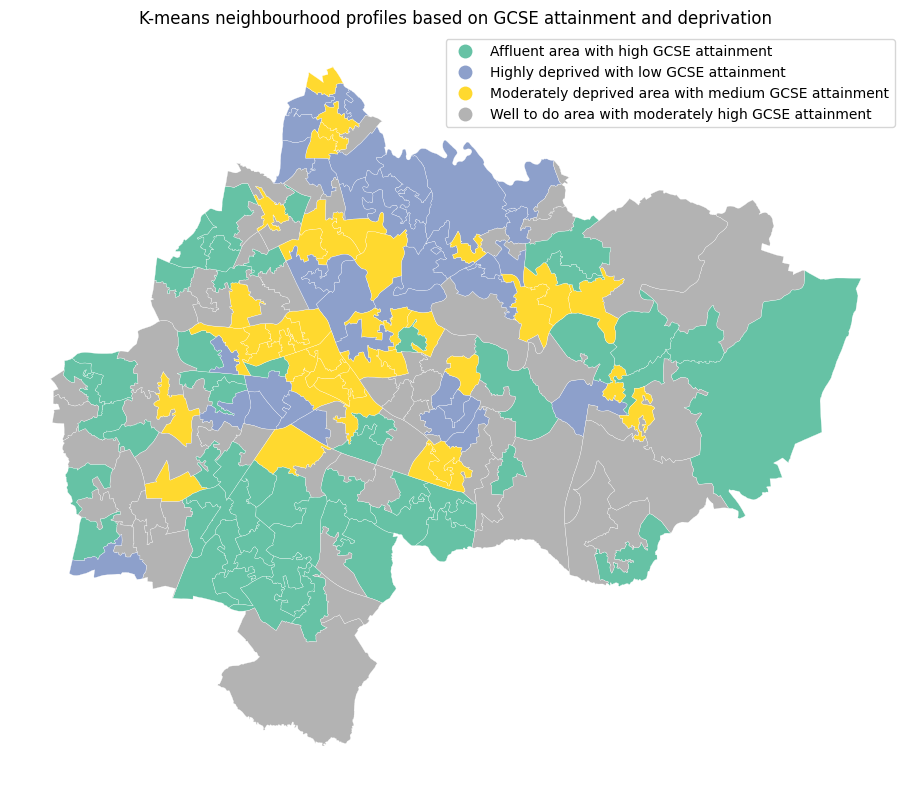

In [ ]:
#Setting figure size
fig, ax = plt.subplots(figsize=(10, 8))

#Creating a map of the above made clusters for LSOA in stockport, making sure to use a colorblind frinedly pallette and turning the legend on.
LSOA_GCSE_IMD.plot(
    column='Cluster label',
    categorical=True,
    legend=True,
    ax=ax,
    edgecolor='white',
    linewidth=0.2,
    cmap='Set2'
)

#Adding a title to the map.
ax.set_title('K-means neighbourhood profiles based on GCSE attainment and deprivation')
ax.axis('off')

#Showng the map.
plt.tight_layout()
plt.show()

# References
Bizxcel. 2023. Grouping Data Naturally with K-mean Clustering. [Online]. [Accessed: 27/04/2026]. Available from: https://www.bizxcel.com/blog/grouping-data-naturally-with-k-mean-clustering#:~:text=K%2Dmean%20clustering%20is%20an,like%20the%20data%20broken%20into.  

Data Mill North. 2017. Stockport GCSE Results. Stockport Metropolitan Borough Council. [Online]. [Accessed: 16/04/2026]. Available from: https://datamillnorth.org/dataset/stockport-gcse-results-vdmqm  

Gov.Uk. File 2: domains of deprivation. Ministry of Housing, Communities & Local Government. [Online]. [Accessed: 16/04/2026]. Available from: https://www.gov.uk/government/statistics/english-indices-of-deprivation-2015  

Hashash, E & Shiekh, R. 2022. A Comparison of the Pearson, Spearman Rank and Kendall Tau Correlation Coefficients Using Quantitative Variables. Asian Journal of Probability and Statistics. [Online]. Vol 20(3): p.36-48. [Accessed: 27/04/2026]. Available from: DOI: 10.9734/AJPAS/2022/v20i3425  

Hodge, L. Little, A. Weldon, M. 2021. GCSE attainment and lifetime earnings. [Online]. Department for Education. [Accessed: 27/04/2026]. Available from: https://assets.publishing.service.gov.uk/media/60c36f0cd3bf7f4bd11a2326/GCSE_Attainment_and_Lifetime_Earnings_PDF3A.pdf  

Open Geography Portal. 2023. Lower Layer Super Output Areas (December 2011) Boundaries EW BFC (V3). ONS Geography. [Online]. [Accessed: 16/04/2026]. Available from: https://geoportal.statistics.gov.uk/datasets/ons::lower-layer-super-output-areas-december-2011-boundaries-ew-bfc-v3/explore?location=53.407414%2C-2.173498%2C12  
